In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_scp_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "cells").is_dir() and (p / "run_pipeline.py").is_file():
            return p
    return start


repo_root = Path(os.environ.get("SCP_ROOT") or _find_scp_root(Path.cwd())).resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


In [2]:
# Paths aligned to the current pipeline
src_path = repo_root / "external_data" / "bio_cell_output" / "pyrFiringRateAvg.csv"
out_dir = repo_root / "external_data" / "bio_cell_output"
time_col = "Time"
rate_col = "AvgFiringRate"

assert src_path.is_file(), f"Missing source curve: {src_path}"
out_dir.mkdir(parents=True, exist_ok=True)

# syn_groups/*.json uses source.path relative to repo_root, e.g.
# external_data/bio_cell_output/pyrFiringRateAvg_gabab_tau10ms_delay50ms.csv


In [3]:
import re
from pathlib import Path
from typing import Optional, Union

TIME_CANDIDATES = [
    r"^time$", r"^t$", r"^t_?ms$", r"^(ms|msec|millisecond)s?$",
    r"^t_?s$", r"^(s|sec|second)s?$"
]
RATE_CANDIDATES = [
    r"^(rate|r|firing(_rate)?)$", r"^(hz)$", r"^(spikes?_per_?s|spikes?/s)$"
]

def _find_col(name_list, cols):
    cols_lower = [c.lower() for c in cols]
    for pat in name_list:
        rx = re.compile(pat, re.IGNORECASE)
        for i, c in enumerate(cols_lower):
            if rx.match(c):
                return i
    return None


def inspect_pn_csv(
    csv_path: Union[str, Path],
    time_col: Optional[str] = None,
    rate_col: Optional[str] = None,
    max_rows: int = 5,
):
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)
    cols = list(df.columns)

    # Prefer explicit columns if provided
    tidx = cols.index(time_col) if (time_col in cols) else None
    ridx = cols.index(rate_col) if (rate_col in cols) else None

    # Try to detect time & rate columns by header names
    if tidx is None:
        tidx = _find_col(TIME_CANDIDATES, cols)
    if ridx is None:
        ridx = _find_col(RATE_CANDIDATES, cols)

    # Heuristics if headers are not clear
    if tidx is None and len(df.columns) > 0:
        first = df.iloc[:, 0]
        if np.issubdtype(first.dtype, np.number):
            vals = first.values
            if vals.size >= 3 and np.all(np.diff(vals[:min(len(vals), 1000)]) > 0):
                tidx = 0

    if ridx is None:
        candidate_idxs = [i for i, c in enumerate(cols) if np.issubdtype(df.iloc[:, i].dtype, np.number)]
        if tidx == 0 and len(candidate_idxs) > 1:
            ridx = 1
        elif candidate_idxs:
            ridx = candidate_idxs[-1]

    # Extract arrays (if present)
    t = df.iloc[:, tidx].to_numpy(dtype=float) if tidx is not None else None
    r = df.iloc[:, ridx].to_numpy(dtype=float) if ridx is not None else None

    # Guess time units and dt
    time_unit = None
    dt_ms = None
    if t is not None and t.size > 1:
        diffs = np.diff(t[:min(len(t), 500)])
        diffs = diffs[np.isfinite(diffs)]
        med_dt = float(np.median(diffs)) if diffs.size else None
        if med_dt is not None:
            if 1e-4 <= med_dt <= 1e-1:
                time_unit = "s"
                dt_ms = med_dt * 1000.0
            else:
                time_unit = "ms"
                dt_ms = med_dt

    print("=== PN CSV Inspection ===")
    print(f"Path: {csv_path}")
    print(f"Columns: {cols}")
    print(f"Detected time column index: {tidx}  ({cols[tidx] if tidx is not None else 'None'})")
    print(f"Detected rate column index: {ridx}  ({cols[ridx] if ridx is not None else 'None'})")
    if t is not None:
        neg = int(np.sum(t < 0))
        print(f"Time unit guess: {time_unit} | dt_ms≈ {None if dt_ms is None else round(dt_ms, 4)}")
        print(f"Time span: {round(t[0],4)} -> {round(t[-1],4)} ({time_unit or 'unknown'})")
        print(f"Negative time samples: {neg}")
        if dt_ms is not None:
            print(f"Suggested source.bin_ms: {round(dt_ms, 4)}")
    else:
        print("No time column detected. We will need dt_ms explicitly.")
    if r is not None:
        print(f"Rate stats (Hz): min={np.nanmin(r):.3f}, max={np.nanmax(r):.3f}, median={np.nanmedian(r):.3f}")
        print("First rows:")
        print(df.head(max_rows).to_string(index=False))
    else:
        print("No rate column detected. Please confirm which column is PN firing rate (Hz).")

    return {
        "df": df,
        "time_idx": tidx,
        "rate_idx": ridx,
        "time_unit": time_unit,
        "dt_ms": dt_ms,
    }


In [4]:
# EXAMPLE USAGE
info = inspect_pn_csv(src_path, time_col=time_col, rate_col=rate_col)


=== PN CSV Inspection ===
Path: /home/hrbncv/SCP/external_data/bio_cell_output/pyrFiringRateAvg.csv
Columns: ['Time', 'AvgFiringRate']
Detected time column index: 0  (Time)
Detected rate column index: 1  (AvgFiringRate)
Time unit guess: s | dt_ms≈ 5.0239
Time span: -0.5 -> 0.55 (s)
Negative time samples: 100
Suggested source.bin_ms: 5.0239
Rate stats (Hz): min=1.764, max=8.841, median=2.378
First rows:
     Time  AvgFiringRate
-0.500000       1.832524
-0.494976       1.777913
-0.489952       1.910059
-0.484928       1.856796
-0.479904       1.763754


In [5]:
# import pandas as pd
# import numpy as np
# from pathlib import Path

# # === CONFIG ===
# tau_s = 0.05   # time constant in seconds (try 0.02-0.2 first)
# init_mode = "match"  # "match" sets S0 = r_norm(0); "zero" sets S0 = 0
# src_path = src_path
# out_path = out_dir / f"{src_path.stem}_gabab_tau{int(round(tau_s*1000))}ms.csv"

# # === LOAD ===
# df = pd.read_csv(src_path)
# t = df[time_col].to_numpy(dtype=float)        # seconds
# r = df[rate_col].to_numpy(dtype=float)        # Hz
# N = r.size
# assert N > 2, "Trace too short."

# # dt in seconds (use median in case of tiny jitter)
# dt = float(np.median(np.diff(t)))
# if not (1e-4 <= dt <= 1.0):
#     raise ValueError(f"Unexpected dt (s): {dt}")

# # === STEP 1: normalize ===
# rmax = max(r.max(), 1e-12)
# r_norm = r / rmax

# # === STEP 2: integrate S' = (r_norm - S)/tau ===
# S = np.zeros_like(r_norm)
# S[0] = r_norm[0] if init_mode == "match" else 0.0
# coef = dt / tau_s
# for i in range(1, N):
#     S[i] = S[i-1] + coef * (r_norm[i-1] - S[i-1])
# # keep S in [0,1] just in case of numeric drift
# S = np.clip(S, 0.0, 1.0)

# # === STEP 3: effective PN->SST drive ===
# I = r * (1.0 - S)
# I[I < 0] = 0.0

# # === SAVE with SAME column names ===
# out_df = pd.DataFrame({time_col: t, rate_col: I})
# out_df.to_csv(out_path, index=False)

# # === QUICK SUMMARY ===
# print("Wrote:", out_path)
# print(f"dt ~= {dt*1000:.3f} ms, tau = {tau_s*1000:.1f} ms")
# print(f"Original rate: min={r.min():.3f} max={r.max():.3f} Hz")
# print(f"Adjusted rate: min={I.min():.3f} max={I.max():.3f} Hz")
# print("Preview:")
# print(out_df.head().to_string(index=False))


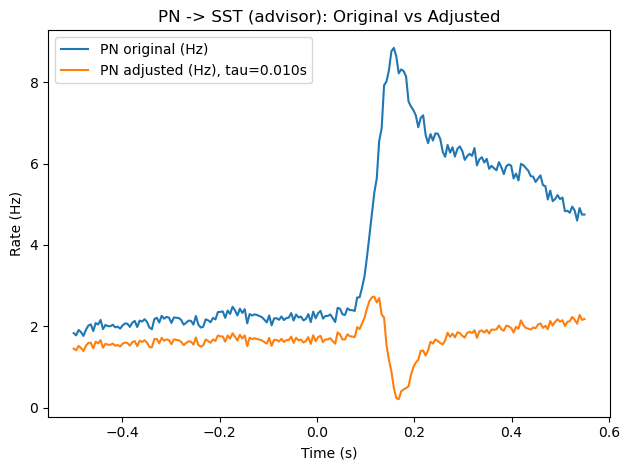

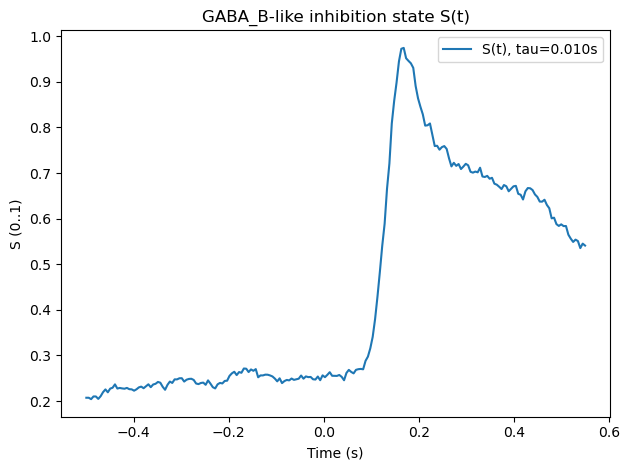

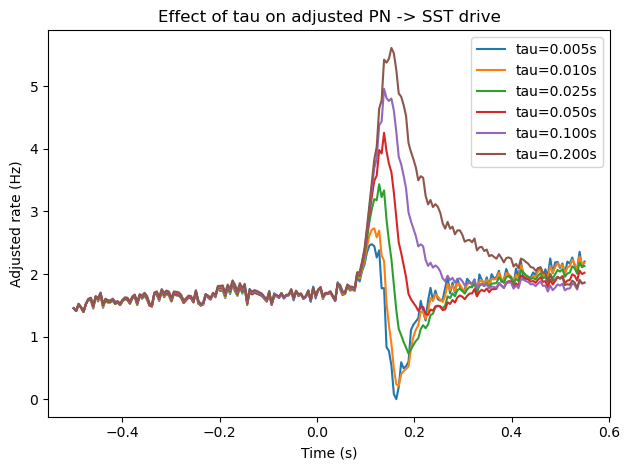

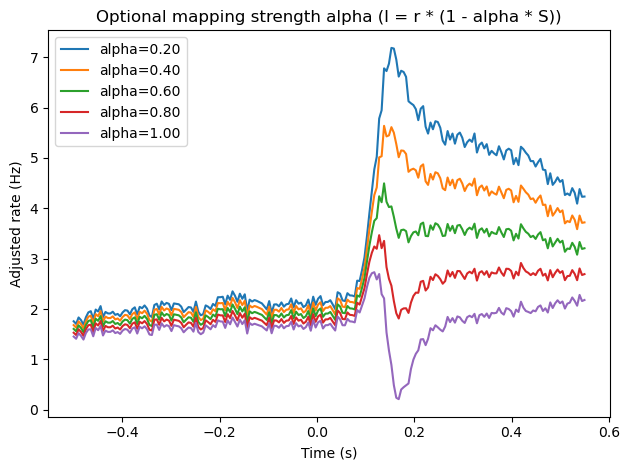

In [6]:
# --- PN -> SST (advisor spec) visualization ---
# Plots: original vs adjusted; S(t); tau sweep; optional alpha sweep
# NOTE: time is in seconds in the CSV, rate is in Hz.

# ---------- Config ----------
baseline_tau_s = 0.01            # main time constant (seconds)
init_mode = "match"              # "match" (S0=r_norm(0)) or "zero"
tau_sweep = [0.005, 0.01, 0.025, 0.05, 0.1, 0.2]
SHOW_ALPHA_SWEEP = True         # set True to view optional alpha sweep
alpha_sweep = [0.2, 0.4, 0.6, 0.8, 1.0]
use_percentile_norm = False      # set True to normalize by 99th percentile
pctl = 99.0

# ---------- Load ----------
df = pd.read_csv(src_path)
t = df[time_col].to_numpy(dtype=float)  # seconds
r = df[rate_col].to_numpy(dtype=float)  # Hz
dt_s = float(np.median(np.diff(t)))
assert 1e-4 <= dt_s <= 1.0, f"Unexpected dt: {dt_s}s"

# ---------- Helper: advisor model ----------
def apply_gabab_simple(r_hz, dt_s, tau_s, init="match", alpha=1.0, *, robust_norm=False, pctl=99.0):
    """
    Advisor equations:
      r_norm = r / r_ref
      dS/dt = (r_norm - S) / tau
      I = r * (1 - alpha * S)
    """
    if tau_s <= 0:
        raise ValueError("tau_s must be > 0")
    r = np.asarray(r_hz, dtype=float)
    if robust_norm:
        r_ref = np.percentile(r, pctl)
    else:
        r_ref = r.max()
    r_ref = max(r_ref, 1e-12)
    r_norm = r / r_ref

    S = np.zeros_like(r_norm)
    S[0] = r_norm[0] if init == "match" else 0.0

    coef = dt_s / tau_s
    for i in range(1, r.size):
        S[i] = S[i-1] + coef * (r_norm[i-1] - S[i-1])
    S = np.clip(S, 0.0, 1.0)

    I = r * (1.0 - alpha * S)
    I[I < 0] = 0.0
    return I, S

# ---------- Baseline ----------
I_base, S_base = apply_gabab_simple(
    r, dt_s, baseline_tau_s, init=init_mode, alpha=1.0,
    robust_norm=use_percentile_norm, pctl=pctl
)

# ---------- Fig 1: PN original vs adjusted (baseline) ----------
plt.figure()
plt.plot(t, r, label="PN original (Hz)")
plt.plot(t, I_base, label=f"PN adjusted (Hz), tau={baseline_tau_s:.3f}s")
plt.title("PN -> SST (advisor): Original vs Adjusted")
plt.xlabel("Time (s)")
plt.ylabel("Rate (Hz)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Fig 2: Inhibition state S(t) ----------
plt.figure()
plt.plot(t, S_base, label=f"S(t), tau={baseline_tau_s:.3f}s")
plt.title("GABA_B-like inhibition state S(t)")
plt.xlabel("Time (s)")
plt.ylabel("S (0..1)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Fig 3: tau sweep ----------
plt.figure()
for tau in tau_sweep:
    I_tau, _ = apply_gabab_simple(
        r, dt_s, tau, init=init_mode, alpha=1.0,
        robust_norm=use_percentile_norm, pctl=pctl
    )
    plt.plot(t, I_tau, label=f"tau={tau:.3f}s")
plt.title("Effect of tau on adjusted PN -> SST drive")
plt.xlabel("Time (s)")
plt.ylabel("Adjusted rate (Hz)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Fig 4 (optional): alpha sweep ----------
if SHOW_ALPHA_SWEEP:
    plt.figure()
    for a in alpha_sweep:
        I_a, _ = apply_gabab_simple(
            r, dt_s, baseline_tau_s, init=init_mode, alpha=a,
            robust_norm=use_percentile_norm, pctl=pctl
        )
        plt.plot(t, I_a, label=f"alpha={a:.2f}")
    plt.title("Optional mapping strength alpha (I = r * (1 - alpha * S))")
    plt.xlabel("Time (s)")
    plt.ylabel("Adjusted rate (Hz)")
    plt.legend()
    plt.tight_layout()
    plt.show()


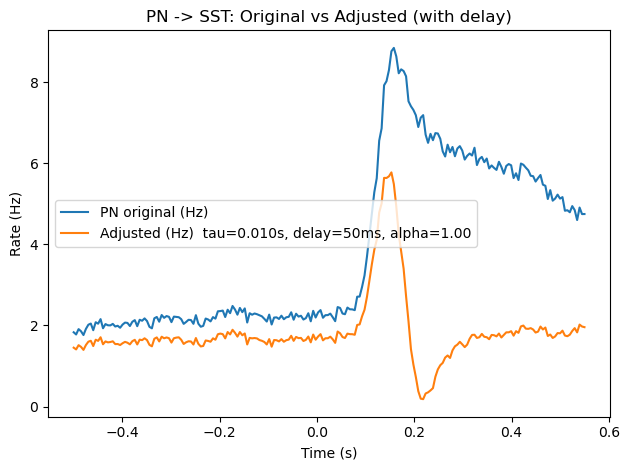

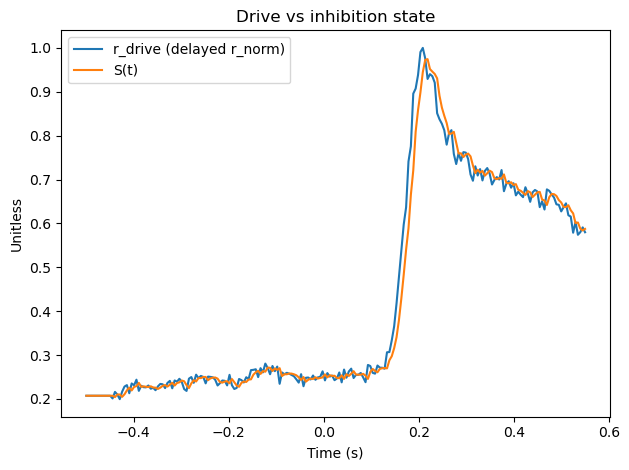

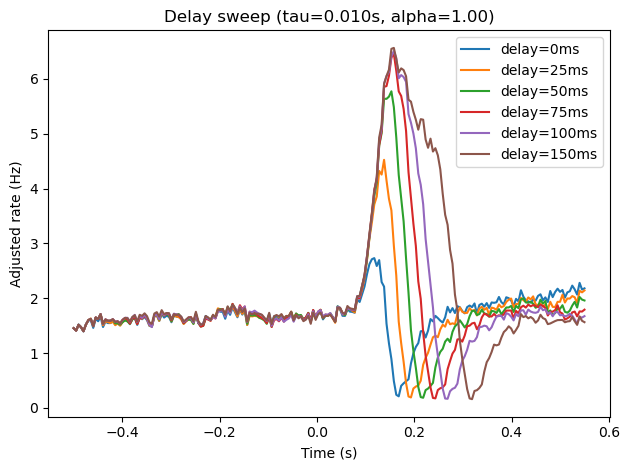

In [7]:
# --- PN -> SST with delay (matches pn_exc_gabab defaults) ---
# Equations:
#   r_norm = r / r_ref
#   dS/dt = (r_drive - S)/tau, where r_drive is r_norm delayed by delay_ms
#   I = r * (1 - alpha * S)

# ---------- Config ----------
# Baseline settings for single-trace view
# Default values match pn_exc_gabab.json

tau_s = 0.01             # seconds (10 ms)
delay_ms = 50.0          # milliseconds
alpha = 1.0              # 1.0 matches advisor mapping; <1 weakens suppression
init_mode = "match"      # "match" (S0=r_norm(0)) or "zero"

# Normalization options
use_percentile_norm = False
pctl = 99.0

# Sweep of delay values (ms) to visualize effect
delay_sweep_ms = [0.0, 25.0, 50.0, 75.0, 100.0, 150.0]

# Save the adjusted trace (using the single delay_ms baseline above)
SAVE = False

# ---------- Load ----------
df = pd.read_csv(src_path)
t = df[time_col].to_numpy(dtype=float)  # seconds
r = df[rate_col].to_numpy(dtype=float)  # Hz
dt_s = float(np.median(np.diff(t)))
assert 1e-4 <= dt_s <= 1.0, f"Unexpected dt: {dt_s}s"

# ---------- Helper ----------
def apply_gabab_delayed(
    r_hz: np.ndarray,
    dt_s: float,
    tau_s: float,
    *,
    delay_ms: float = 0.0,
    alpha: float = 1.0,
    init: str = "match",
    robust_norm: bool = False,
    pctl: float = 99.0,
):
    """
    Advisor core + delay:
      r_ref = max(r) or percentile
      r_norm = r / r_ref
      r_drive = delayed(r_norm, delay_ms)
      S' = (r_drive - S)/tau
      I = r * (1 - alpha * S)
    """
    if tau_s <= 0:
        raise ValueError("tau_s must be > 0")
    r = np.asarray(r_hz, dtype=float)
    N = r.size

    # Normalization
    r_ref = np.percentile(r, pctl) if robust_norm else r.max()
    r_ref = max(r_ref, 1e-12)
    r_norm = r / r_ref

    # Delay (in samples)
    k = int(round((delay_ms / 1000.0) / max(dt_s, 1e-12)))
    if k <= 0:
        r_drive = r_norm
    elif k >= N:
        base = r_norm[0] if init == "match" else 0.0
        r_drive = np.full_like(r_norm, base)
    else:
        base = r_norm[0] if init == "match" else 0.0
        r_drive = np.empty_like(r_norm)
        r_drive[:k] = base
        r_drive[k:] = r_norm[:-k]

    # Integrate S
    S = np.zeros_like(r_norm)
    S[0] = r_norm[0] if init == "match" else 0.0
    coef = dt_s / tau_s
    for i in range(1, N):
        S[i] = S[i-1] + coef * (r_drive[i-1] - S[i-1])
    S = np.clip(S, 0.0, 1.0)

    # Map to adjusted PN->SST drive
    I = r * (1.0 - alpha * S)
    I[I < 0] = 0.0
    return I, S, r_drive

# ---------- Baseline plots ----------
I_base, S_base, r_drive_base = apply_gabab_delayed(
    r, dt_s, tau_s,
    delay_ms=delay_ms,
    alpha=alpha,
    init=init_mode,
    robust_norm=use_percentile_norm,
    pctl=pctl,
)

plt.figure()
plt.plot(t, r, label="PN original (Hz)")
plt.plot(t, I_base, label=f"Adjusted (Hz)  tau={tau_s:.3f}s, delay={delay_ms:.0f}ms, alpha={alpha:.2f}")
plt.title("PN -> SST: Original vs Adjusted (with delay)")
plt.xlabel("Time (s)")
plt.ylabel("Rate (Hz)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(t, r_drive_base, label="r_drive (delayed r_norm)")
plt.plot(t, S_base, label="S(t)")
plt.title("Drive vs inhibition state")
plt.xlabel("Time (s)")
plt.ylabel("Unitless")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Delay sweep ----------
plt.figure()
for dms in delay_sweep_ms:
    I_d, _, _ = apply_gabab_delayed(
        r, dt_s, tau_s,
        delay_ms=dms,
        alpha=alpha,
        init=init_mode,
        robust_norm=use_percentile_norm,
        pctl=pctl,
    )
    plt.plot(t, I_d, label=f"delay={dms:.0f}ms")
plt.title(f"Delay sweep (tau={tau_s:.3f}s, alpha={alpha:.2f})")
plt.xlabel("Time (s)")
plt.ylabel("Adjusted rate (Hz)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Save (optional) ----------
if SAVE:
    out_name = f"{src_path.stem}_gabab_tau{int(round(tau_s*1000))}ms_delay{int(round(delay_ms))}ms.csv"
    out_path = out_dir / out_name
    out_df = pd.DataFrame({time_col: t, rate_col: I_base})
    out_df.to_csv(out_path, index=False)
    print("Wrote:", out_path)
    try:
        print("syn_groups source.path:", out_path.relative_to(repo_root))
    except ValueError:
        pass


# Legacy exponential filter (optional)

This section preserves the older exponential suppression rule for reference only.
The current pipeline uses the ODE-based GABAB filter above.


In [8]:
RUN_LEGACY = False  # set True to run the legacy exponential filter below


In [9]:
if RUN_LEGACY:
    df = pd.read_csv(src_path)
    t = df[time_col].to_numpy(dtype=float)
    r = df[rate_col].to_numpy(dtype=float)

    legacy_params = {
        "stim_delay_ms": 100.0,
        "beta": 0.5,
        "tau_ms": 200.0,
    }


In [10]:
if RUN_LEGACY:
    inh_curve = []
    for fr_time_s, fr in zip(t, r):
        fr_time_ms = fr_time_s * 1000.0
        if fr_time_ms <= legacy_params["stim_delay_ms"]:
            inh_curve.append(fr)
        else:
            inh_multi = legacy_params["beta"] * (
                1.0 - np.exp(-(fr_time_ms - legacy_params["stim_delay_ms"]) / legacy_params["tau_ms"])
            )
            inh_curve.append(fr * (1.0 - inh_multi))

    inh_curve = np.asarray(inh_curve, dtype=float)

    SAVE_LEGACY = False
    if SAVE_LEGACY:
        out_name = (
            f"{src_path.stem}_legacy_beta{legacy_params['beta']}_"
            f"tau{int(legacy_params['tau_ms'])}ms_delay{int(legacy_params['stim_delay_ms'])}ms.csv"
        )
        out_path = out_dir / out_name
        out_df = pd.DataFrame({time_col: t, rate_col: inh_curve})
        out_df.to_csv(out_path, index=False)
        print("Wrote:", out_path)


In [11]:
if RUN_LEGACY:
    plt.figure()
    plt.plot(t, r, color="g", label="Original")
    plt.plot(t, inh_curve, color="r", label="Legacy adjusted")
    plt.xlabel("Time (s)")
    plt.ylabel("Rate (Hz)")
    plt.legend()
    plt.tight_layout()
    plt.show()
